In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# 1. Nạp dữ liệu từ thư mục interim
data_path = "../data/interim/extracted_data.csv"
print("Đang nạp dữ liệu từ local...")
df = pd.read_csv(data_path)
print(f"Kích thước bộ dữ liệu thô: {df.shape}")
df.head(3)

Đang nạp dữ liệu từ local...
Kích thước bộ dữ liệu thô: (7043, 16)


,ID,Churn,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaymentMethod,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport
0,0002-ORFBO,0,0,1,No,9,12,Mailed check,1,65.6,593.30,DSL,0,1,0,1
1,0003-MKNFE,0,0,0,No,9,1,Mailed check,0,59.9,542.40,DSL,0,0,0,0
2,0004-TLHLJ,1,0,0,No,4,1,Electronic check,1,73.9,280.85,Fiber optic,0,0,1,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   Contract          7043 non-null   int64  
 7   PaymentMethod     7043 non-null   object 
 8   PaperlessBilling  7043 non-null   int64  
 9   MonthlyCharges    7043 non-null   float64
 10  TotalCharges      7043 non-null   float64
 11  InternetService   7043 non-null   object 
 12  OnlineSecurity    7043 non-null   int64  
 13  OnlineBackup      7043 non-null   int64  
 14  DeviceProtection  7043 non-null   int64  
 15  TechSupport       7043 non-null   int64  
dtypes: float64(2), int64(10), object(4)
memory

In [3]:
df.describe()

,Churn,SeniorCitizen,Partner,Tenure,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,32.371149,8.835865,0.592219,64.761692,2279.734304,0.286668,0.344881,0.343888,0.290217
std,0.441561,0.368612,0.499748,24.559481,9.551444,0.491457,30.090047,2266.794470,0.452237,0.475363,0.475038,0.453895
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,55.000000,12.000000,1.000000,89.850000,3786.600000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,72.000000,24.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000


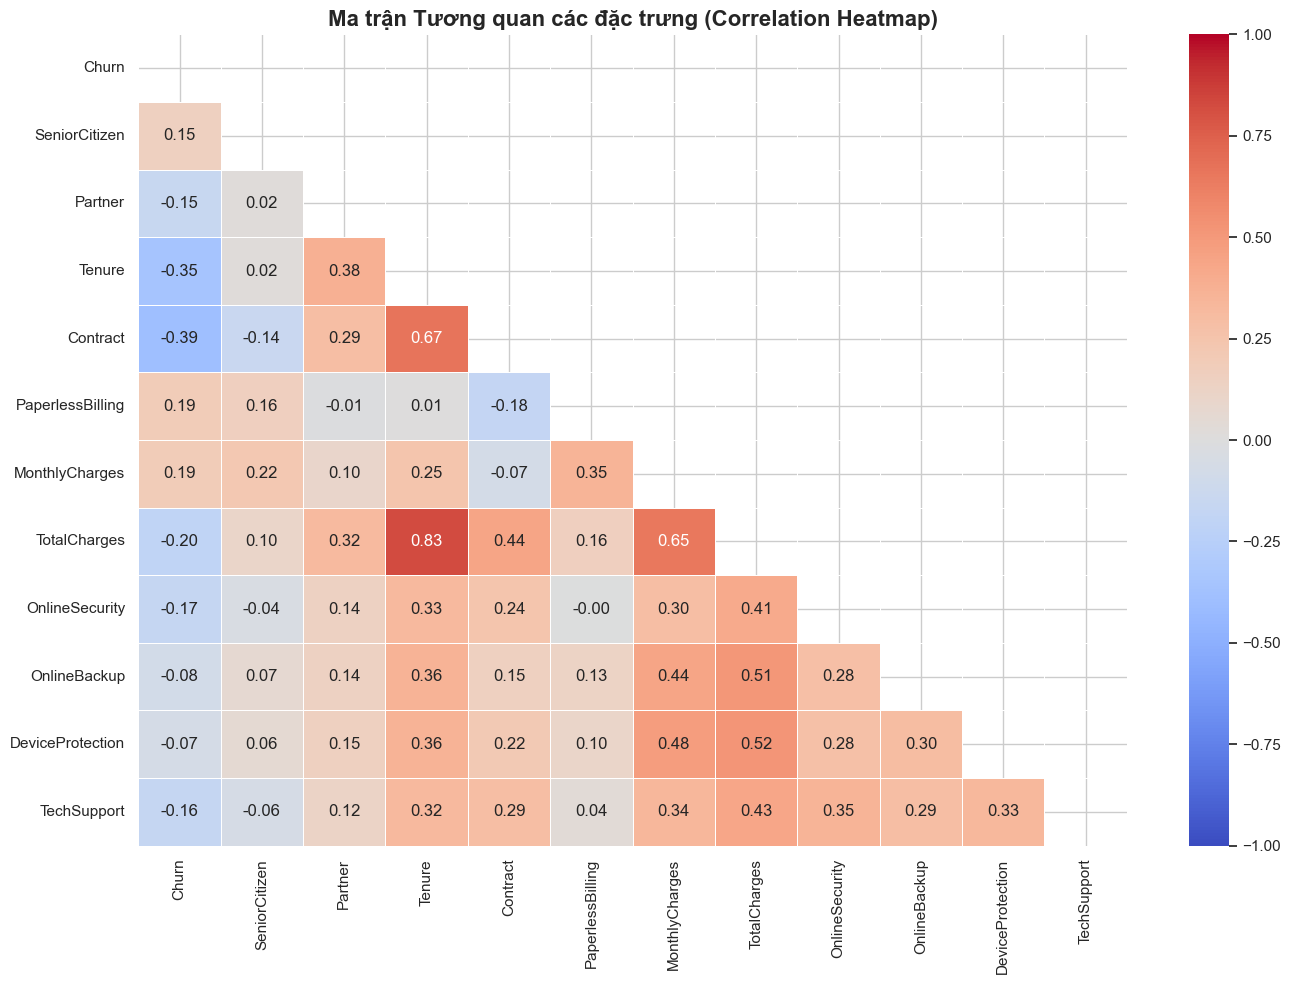

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Giả định DataFrame của bạn tên là df
# Đảm bảo các biến phân loại (như Churn) đã được map về số (0, 1) nếu cần đưa vào heatmap
plt.figure(figsize=(14, 10))

# Chỉ lấy các cột định lượng để tính tương quan
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[num_cols].corr()

# TẠO MASK: Che đi nửa trên của ma trận và đường chéo chính (giá trị 1)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Vẽ Heatmap (đã thêm tham số mask=mask)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)

plt.title("Ma trận Tương quan các đặc trưng (Correlation Heatmap)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

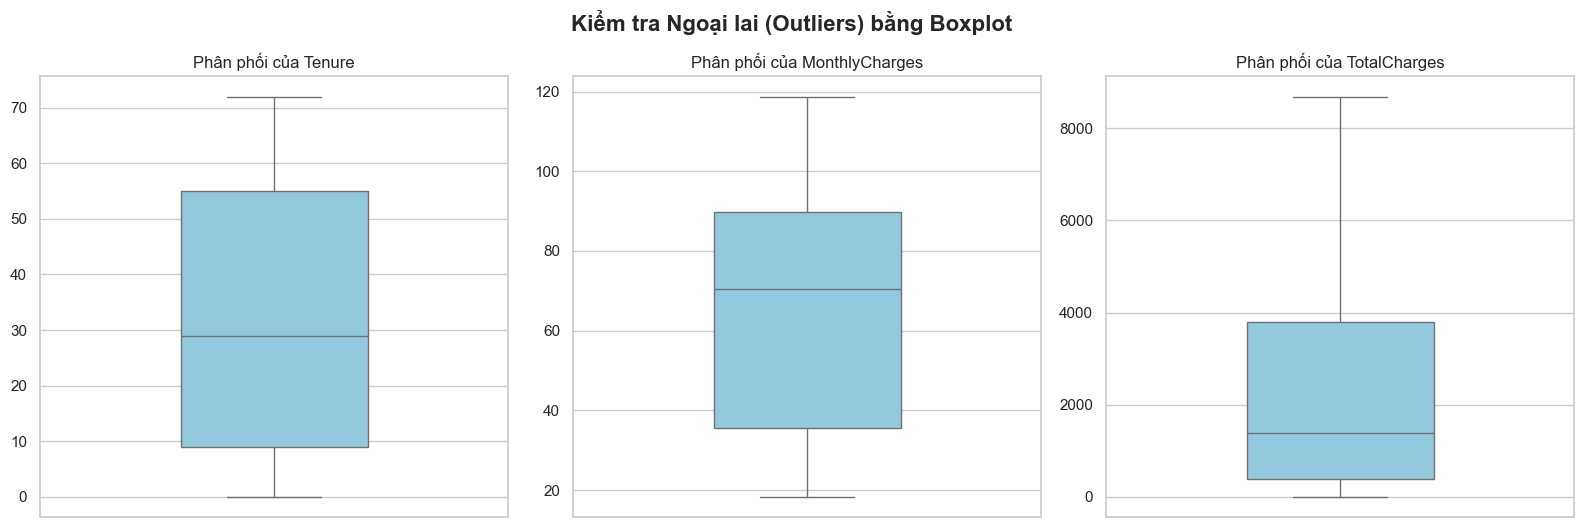

In [9]:
# Cập nhật danh sách cột số cần check outlier dựa trên df.info()
outlier_features = ['Tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(16, 5))
for i, col in enumerate(outlier_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue', width=0.4)
    plt.title(f'Phân phối của {col}', fontsize=12)
    plt.ylabel('')

plt.tight_layout()
plt.suptitle("Kiểm tra Ngoại lai (Outliers) bằng Boxplot", fontsize=16, fontweight='bold', y=1.05)
plt.show()

C:\Users\HGB\AppData\Local\Temp\ipykernel_10824\748464471.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Tenure', palette='Set2', ax=ax[1], width=0.5)


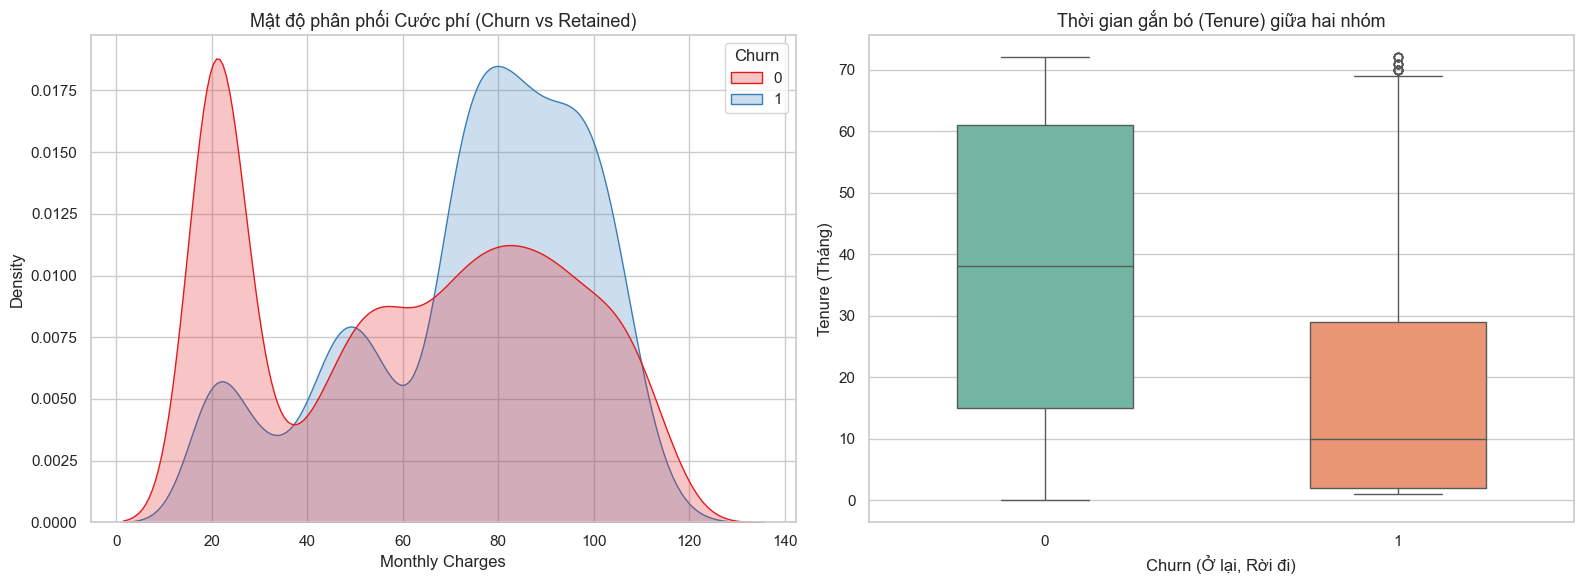

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Phân bố cước phí hàng tháng theo nhóm Churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='Set1', ax=ax[0])
ax[0].set_title('Mật độ phân phối Cước phí (Churn vs Retained)', fontsize=13)
ax[0].set_xlabel('Monthly Charges')
ax[0].set_ylabel('Density')

# 2. Boxplot thời gian sử dụng (Tenure) theo Churn
sns.boxplot(data=df, x='Churn', y='Tenure', palette='Set2', ax=ax[1], width=0.5)
ax[1].set_title('Thời gian gắn bó (Tenure) giữa hai nhóm', fontsize=13)
ax[1].set_xlabel('Churn (0 = Ở lại, 1 = Rời đi)')
ax[1].set_ylabel('Tenure (Tháng)')

plt.tight_layout()
plt.show()

C:\Users\HGB\AppData\Local\Temp\ipykernel_10824\525017005.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette=['#2ca02c', '#d62728'], ax=axes[i, 1], width=0.4)
C:\Users\HGB\AppData\Local\Temp\ipykernel_10824\525017005.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['0 (Ở lại)', '1 (Rời đi)'])
C:\Users\HGB\AppData\Local\Temp\ipykernel_10824\525017005.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette=['#2ca02c', '#d62728'], ax=axes[i, 1], width=0.4)
C:\Users\HGB\AppData\Local\Temp\ipykernel_10824\5250170

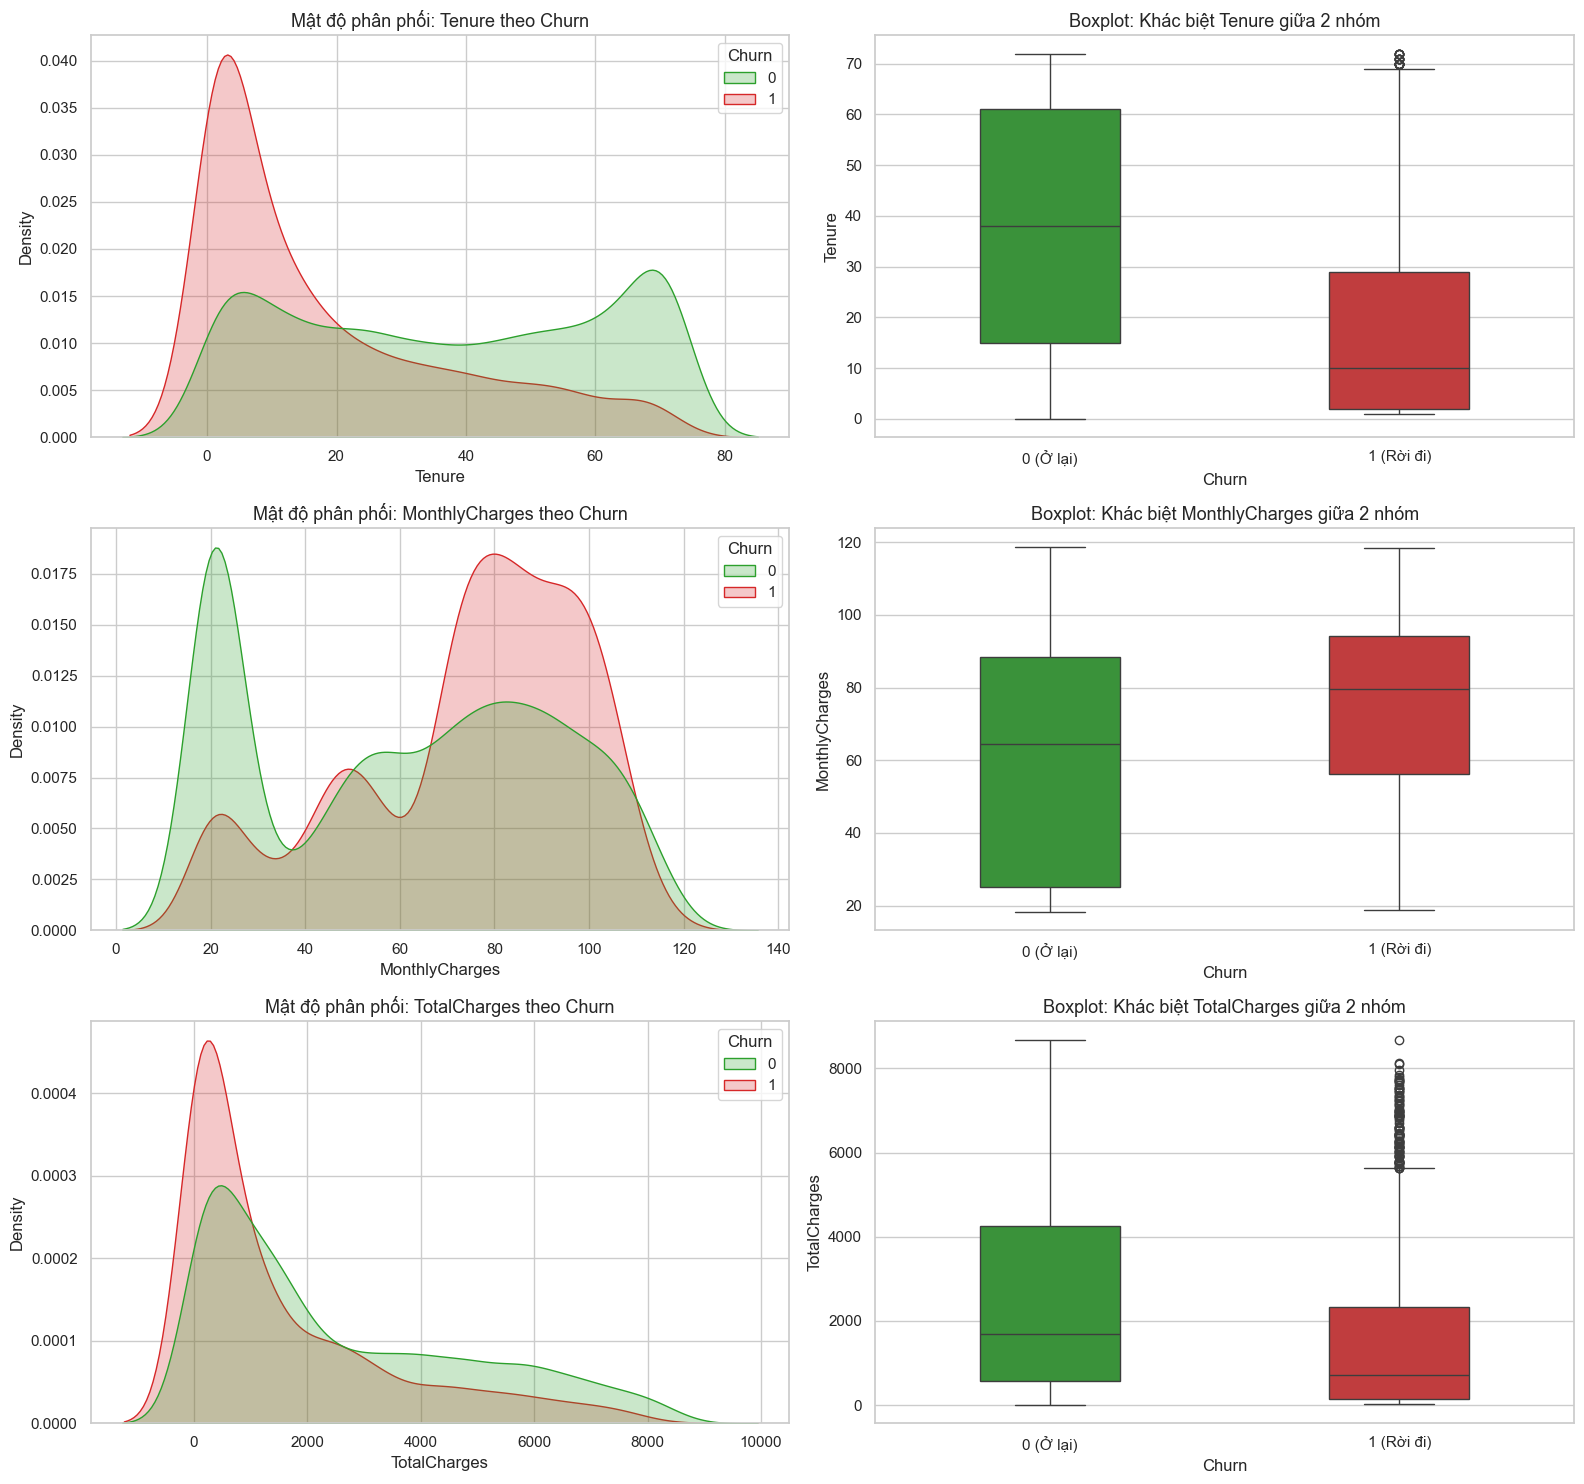

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các biến liên tục cần phân tích
continuous_vars = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# Thiết lập khung biểu đồ (grid)
fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(16, 5 * len(continuous_vars)))

for i, col in enumerate(continuous_vars):
    # 1. KDE Plot: Xem mật độ phân phối
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette=['#2ca02c', '#d62728'], ax=axes[i, 0])
    axes[i, 0].set_title(f'Mật độ phân phối: {col} theo Churn', fontsize=13)
    axes[i, 0].set_ylabel('Density')
    
    # 2. Boxplot: Xem các điểm tập trung và ngoại lai (Outliers)
    sns.boxplot(data=df, x='Churn', y=col, palette=['#2ca02c', '#d62728'], ax=axes[i, 1], width=0.4)
    axes[i, 1].set_title(f'Boxplot: Khác biệt {col} giữa 2 nhóm', fontsize=13)
    axes[i, 1].set_xticklabels(['0 (Ở lại)', '1 (Rời đi)'])

plt.tight_layout()
plt.show()

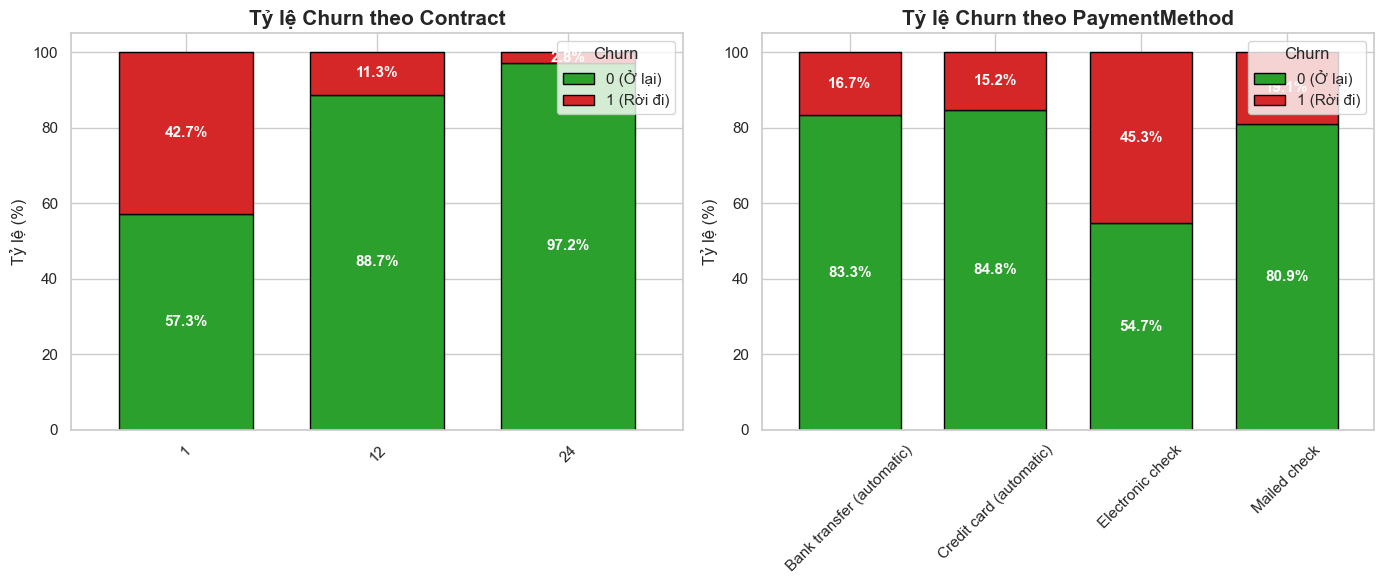

In [14]:
# Danh sách các biến phân loại cần phân tích
categorical_vars = ['Contract', 'PaymentMethod', 'tenure_group']

# Lọc ra các cột thực sự tồn tại trong df (để tránh lỗi nếu chưa chạy Feature Engineering)
cols_to_plot = [col for col in categorical_vars if col in df.columns]

if cols_to_plot:
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(7 * len(cols_to_plot), 6))
    
    # Nếu chỉ có 1 biểu đồ thì biến axes thành mảng 1 chiều để dễ lặp
    if len(cols_to_plot) == 1:
        axes = [axes]

    for i, col in enumerate(cols_to_plot):
        # Tính tỷ lệ % Churn cho từng nhóm của biến phân loại
        churn_pct = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
        
        # Vẽ biểu đồ cột chồng
        ax = churn_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ca02c', '#d62728'], edgecolor='black', width=0.7)
        
        axes[i].set_title(f'Tỷ lệ Churn theo {col}', fontsize=15, fontweight='bold')
        axes[i].set_ylabel('Tỷ lệ (%)')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='Churn', labels=['0 (Ở lại)', '1 (Rời đi)'], loc='upper right')
        
        # Ghi số % trực tiếp lên giữa các cột cho dễ nhìn
        for p in axes[i].patches:
            width, height = p.get_width(), p.get_height()
            x, y = p.get_xy() 
            if height > 2:  # Chỉ in số nếu phần trăm > 2% để tránh text đè lên nhau
                axes[i].text(x + width/2, y + height/2, f'{height:.1f}%', 
                             ha='center', va='center', color='white', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy các cột phân loại trong DataFrame. Vui lòng kiểm tra lại tên cột.")

[TENURE] - KẾT QUẢ KIỂM TRA NGOẠI LAI:
  * Phương pháp IQR    | Ngưỡng: [-60.00 đến 124.00] -> Số lượng Outlier: 0
  * Phương pháp Z-score| Ngưỡng: [-41.31 đến 106.05] -> Số lượng Outlier: 0
---------------------------------------------------------------------------


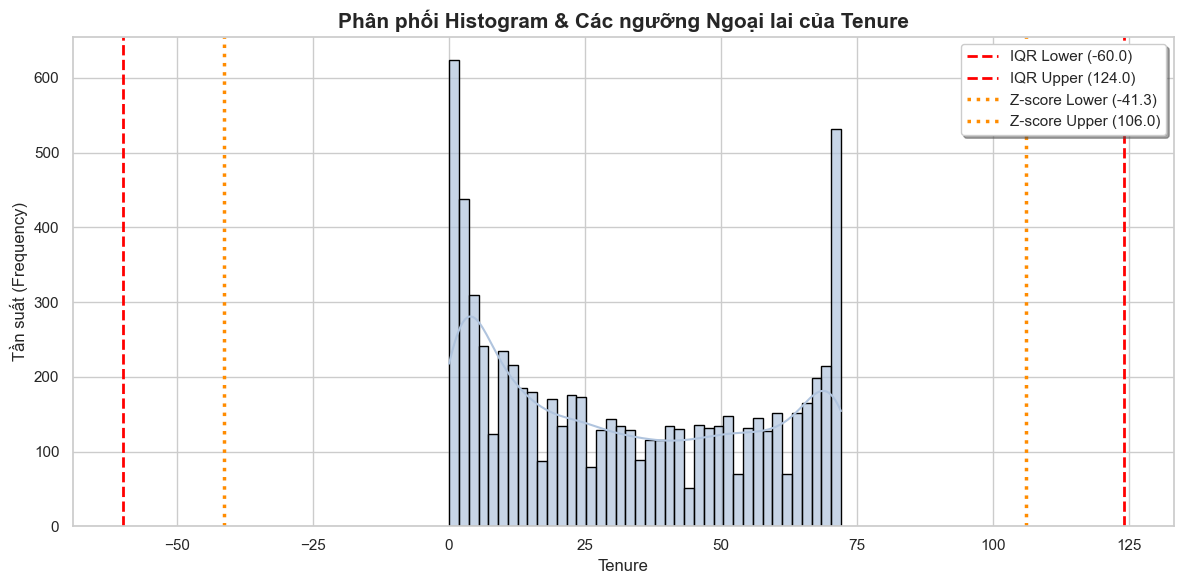

[MONTHLYCHARGES] - KẾT QUẢ KIỂM TRA NGOẠI LAI:
  * Phương pháp IQR    | Ngưỡng: [-46.02 đến 171.38] -> Số lượng Outlier: 0
  * Phương pháp Z-score| Ngưỡng: [-25.51 đến 155.03] -> Số lượng Outlier: 0
---------------------------------------------------------------------------


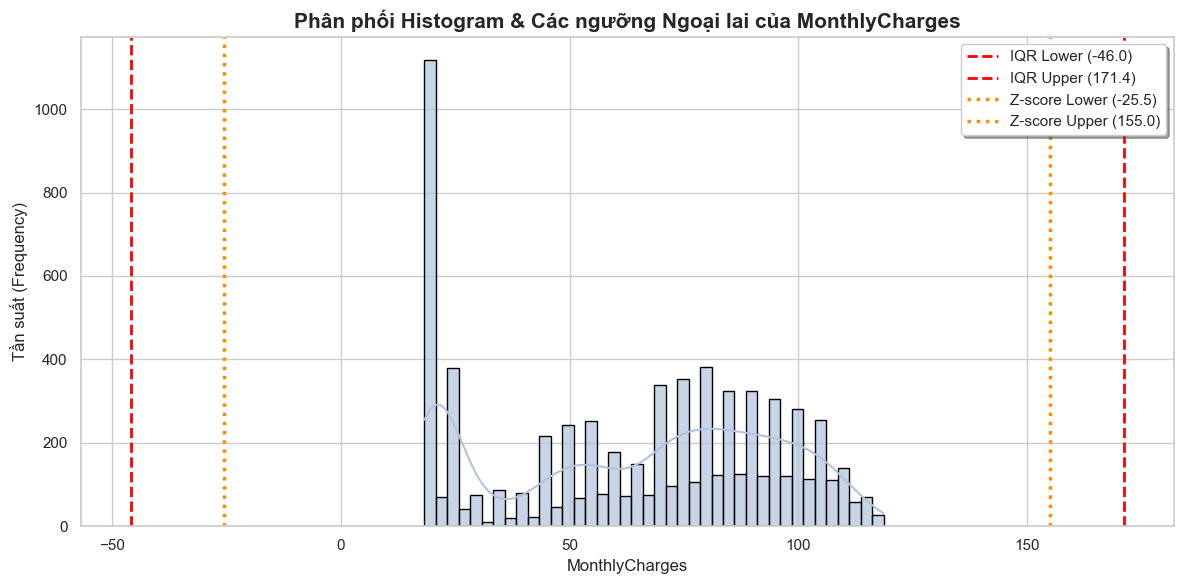

[TOTALCHARGES] - KẾT QUẢ KIỂM TRA NGOẠI LAI:
  * Phương pháp IQR    | Ngưỡng: [-4683.52 đến 8868.67] -> Số lượng Outlier: 0
  * Phương pháp Z-score| Ngưỡng: [-4520.65 đến 9080.12] -> Số lượng Outlier: 0
---------------------------------------------------------------------------


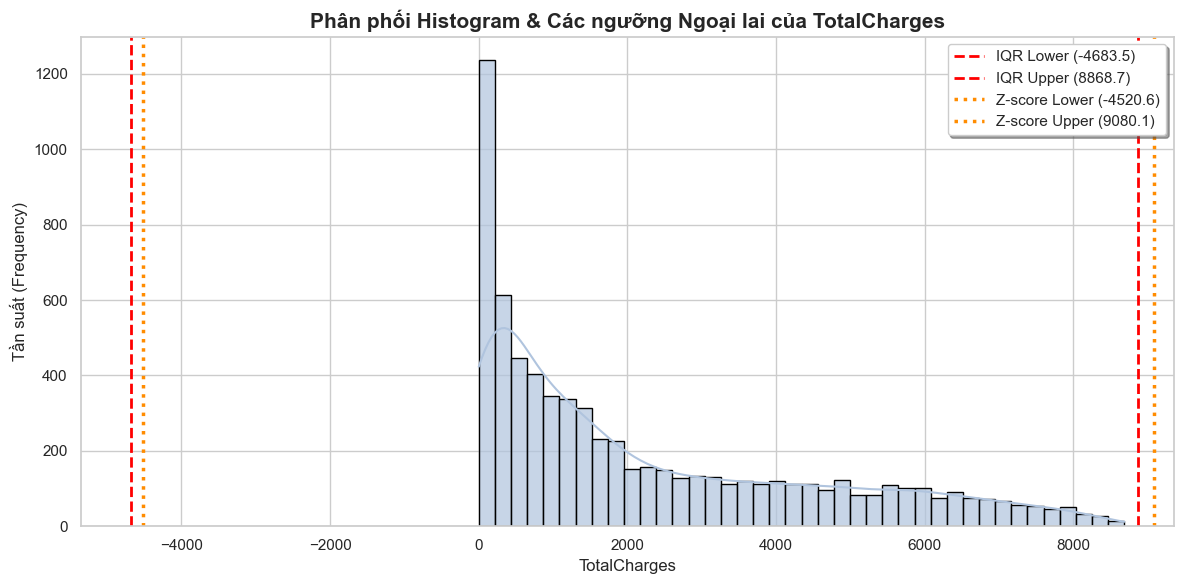

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dựa theo df.info() của bạn, chúng ta lấy 3 cột số thực tế
outlier_features = ['Tenure', 'MonthlyCharges', 'TotalCharges']

for col in outlier_features:
    # Lấy dữ liệu cột (có thể dropna để an toàn tính toán)
    data = df[col].dropna()
    
    # ==========================================
    # 1. TÍNH TOÁN NGƯỠNG IQR
    # ==========================================
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR
    
    # Đếm số lượng điểm vượt ngưỡng IQR
    outliers_iqr = data[(data < iqr_lower) | (data > iqr_upper)].count()
    
    # ==========================================
    # 2. TÍNH TOÁN NGƯỠNG Z-SCORE (Standard)
    # ==========================================
    mean_val = data.mean()
    std_val = data.std()
    z_lower = mean_val - 3 * std_val
    z_upper = mean_val + 3 * std_val
    
    # Đếm số lượng điểm vượt ngưỡng Z-score
    outliers_z = data[(data < z_lower) | (data > z_upper)].count()
    
    # ==========================================
    # 3. IN BÁO CÁO RA CONSOLE (Dành cho AI Audit Log)
    # ==========================================
    print(f"[{col.upper()}] - KẾT QUẢ KIỂM TRA NGOẠI LAI:")
    print(f"  * Phương pháp IQR    | Ngưỡng: [{iqr_lower:.2f} đến {iqr_upper:.2f}] -> Số lượng Outlier: {outliers_iqr}")
    print(f"  * Phương pháp Z-score| Ngưỡng: [{z_lower:.2f} đến {z_upper:.2f}] -> Số lượng Outlier: {outliers_z}")
    print("-" * 75)
    
    # ==========================================
    # 4. VẼ HISTOGRAM KẾT HỢP RANH GIỚI
    # ==========================================
    plt.figure(figsize=(12, 6))
    
    # Vẽ Histogram và đường cong mật độ (KDE)
    sns.histplot(data, kde=True, color='lightsteelblue', bins=40, edgecolor='black', alpha=0.7)
    
    # Vẽ các đường ranh giới IQR (Màu đỏ, Nét đứt)
    plt.axvline(iqr_lower, color='red', linestyle='--', linewidth=2, label=f'IQR Lower ({iqr_lower:.1f})')
    plt.axvline(iqr_upper, color='red', linestyle='--', linewidth=2, label=f'IQR Upper ({iqr_upper:.1f})')
    
    # Vẽ các đường ranh giới Z-score (Màu cam, Nét chấm)
    plt.axvline(z_lower, color='darkorange', linestyle=':', linewidth=2.5, label=f'Z-score Lower ({z_lower:.1f})')
    plt.axvline(z_upper, color='darkorange', linestyle=':', linewidth=2.5, label=f'Z-score Upper ({z_upper:.1f})')
    
    # Trang trí biểu đồ
    plt.title(f'Phân phối Histogram & Các ngưỡng Ngoại lai của {col}', fontsize=15, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Tần suất (Frequency)', fontsize=12)
    plt.legend(loc='upper right', frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.show()